In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
!cp -r "/content/drive/MyDrive/SIH_Crop_Project/potato_dataset/data_potato_processesd_3" /content/

In [4]:
train_dir = "/content/data_potato_processesd_3/train"
val_dir = "/content/data_potato_processesd_3/val"
test_dir = "/content/data_potato_processesd_3/test"

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    zoom_range=0.2,

    width_shift_range=0.1,
    height_shift_range=0.1,

    shear_range=0.1,

    brightness_range=[0.9, 1.3],

    horizontal_flip=True,

    fill_mode='nearest'
)

In [7]:
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [8]:
#train loader
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 2544 images belonging to 3 classes.


In [9]:
#validation loader
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 479 images belonging to 3 classes.


In [10]:
#test loader
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 161 images belonging to 3 classes.


In [11]:
print(train_generator.class_indices)

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}


In [12]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 3)


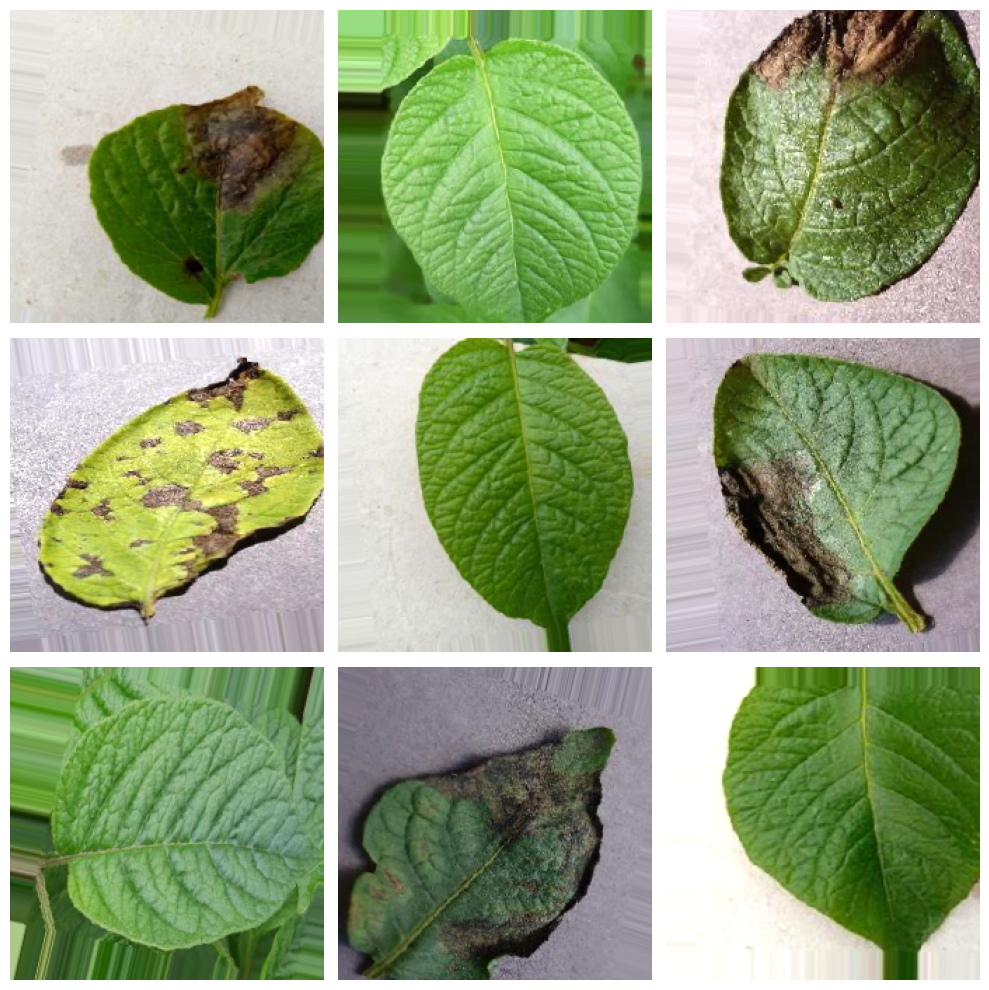

In [13]:
#Augmented Image Visualisation
import matplotlib.pyplot as plt

# Ek batch lo
images, labels = next(train_generator)

# 9 images show karo
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

**CNN**

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D

model = Sequential([

    Conv2D(32, (3,3), activation='relu',padding="same", input_shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu',padding="same"),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu',padding="same"),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu',padding="same"),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu',padding="same"),
    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(512, activation='relu'),
    Dropout(0.6),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 54, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,65

 Total params: 4,980,387 (19.00 MB)

 Trainable params: 4,978,403 (18.99 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

In [18]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
)

Epoch 1/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 90s 792ms/step - accuracy: 0.7484 - loss: 0.7234 - val_accuracy: 0.3173 - val_loss: 2.8140 - learning_rate: 0.0010
Epoch 2/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 527ms/step - accuracy: 0.8667 - loss: 0.4215 - val_accuracy: 0.3424 - val_loss: 2.3067 - learning_rate: 0.0010
Epoch 3/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 530ms/step - accuracy: 0.9006 - loss: 0.3283 - val_accuracy: 0.3737 - val_loss: 1.5502 - learning_rate: 0.0010
Epoch 4/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 536ms/step - accuracy: 0.9159 - loss: 0.2487 - val_accuracy: 0.3445 - val_loss: 3.0004 - learning_rate: 0.0010
Epoch 5/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 532ms/step - accuracy: 0.9410 - loss: 0.1764 - val_accuracy: 0.3695 - val_loss: 3.2215 - learning_rate: 0.0010
Epoch 6/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 523ms/step - accuracy: 0.9575 - loss: 0.1286 - val_accuracy: 0.9353 - val_loss: 0.2062 - learning_rate: 5.0000e-04
Epoch 7/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 508ms/step - accuracy: 0.9548 - loss

In [19]:
model.save('/content/drive/MyDrive/SIH_Crop_Project/potato_models/potato_model_18.keras')

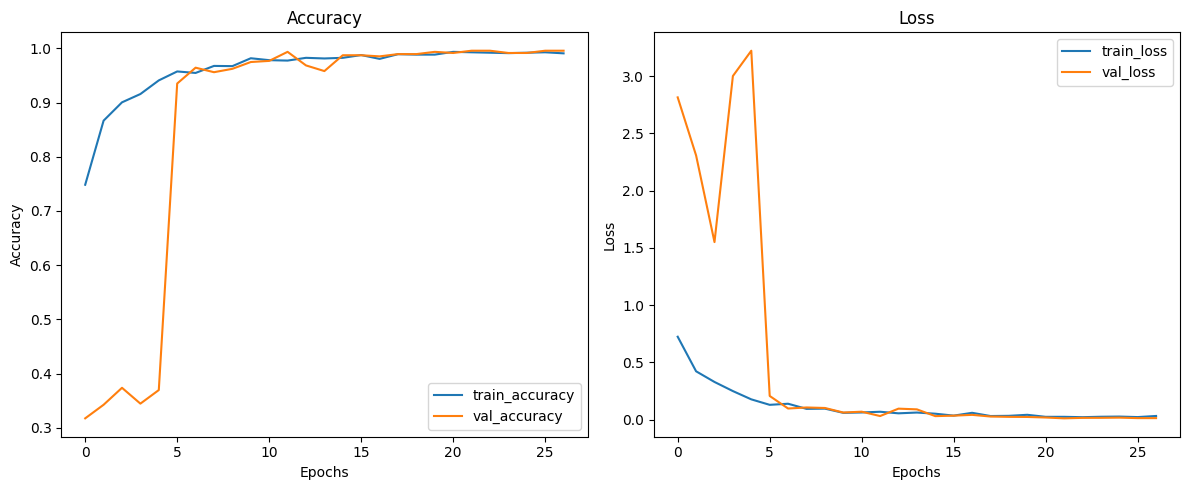

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 362ms/step - accuracy: 0.9876 - loss: 0.0205
Test Loss : 0.020494351163506508
Test Accuracy : 0.9875776171684265


In [22]:
import numpy as np

Y_pred = model.predict(test_generator)

y_pred = np.argmax(Y_pred, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step


In [23]:
y_true = test_generator.classes
print(y_true)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [24]:
class_names = list(test_generator.class_indices.keys())

print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                       precision    recall  f1-score   support

Potato___Early_blight       0.98      0.98      0.98        53
 Potato___Late_blight       0.98      0.98      0.98        58
     Potato___healthy       1.00      1.00      1.00        50

             accuracy                           0.99       161
            macro avg       0.99      0.99      0.99       161
         weighted avg       0.99      0.99      0.99       161



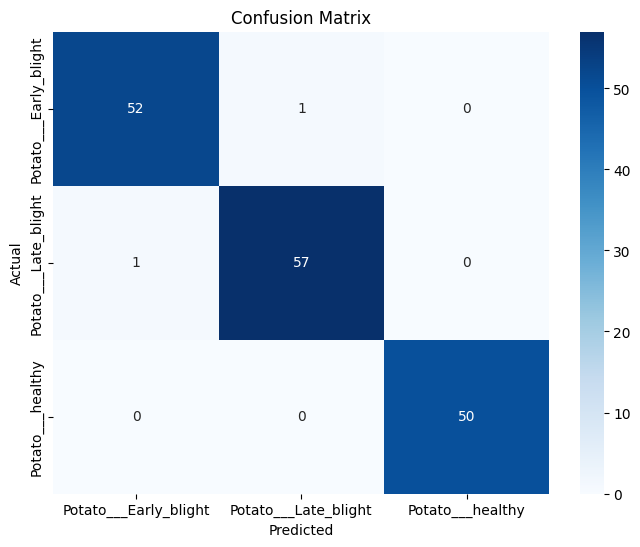

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [27]:
import json

with open("Corn_History_07.json","w") as f:
    json.dump(history.history, f)